In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys

sys.path.insert(0, str(Path.cwd().parent / "src"))
from BradleyTerry import BradleyTerry, DOCS_DIR

"""Plot setup"""
sns.set_style("whitegrid")
sns.set_color_codes(palette="colorblind")

plt.rcParams.update({
	"text.usetex": False,  # keep False to avoid requiring a LaTeX installation
	"mathtext.fontset": "cm",  # Computer Modern (LaTeX-like)
	"font.family": "serif",
	"font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 14,      # increase axis label size
    "axes.titlesize": 16,
    "xtick.labelsize": 14,     # increase tick / bin label size
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

In [18]:
num_routes = 10
num_comparisons = 20

recorded_runs = []

for comparison_idx in range(num_comparisons):
    comparison = [0] * num_routes

    winner_idx, loser_idx = random.sample(range(0, num_routes), 2)

    comparison[winner_idx] = 1
    comparison[loser_idx] = -1

    recorded_runs.append(comparison)

recorded_runs = np.array(recorded_runs)

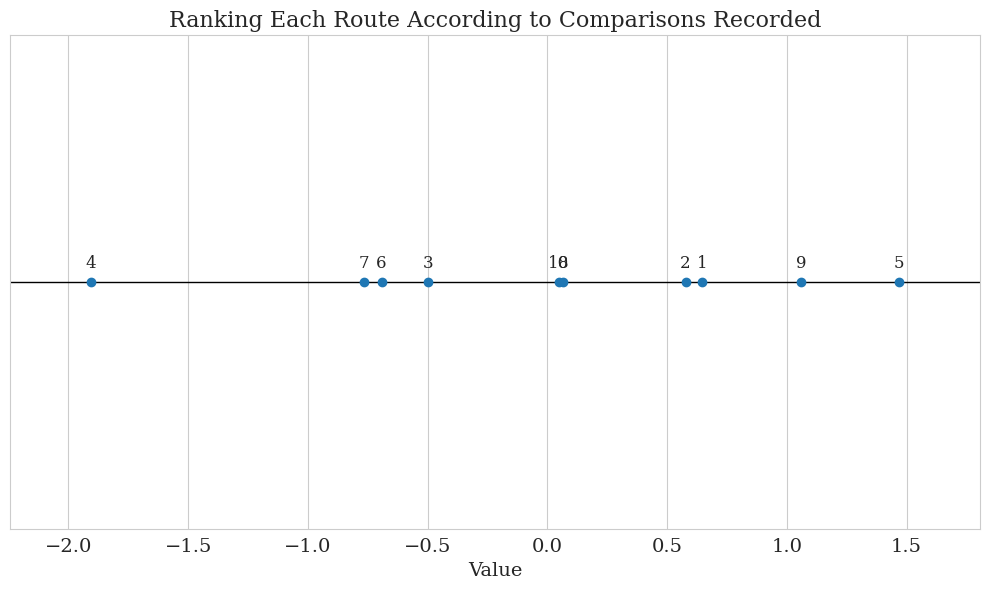

In [19]:
bt = BradleyTerry(num_routes=num_routes)

for comparison_idx in range(num_comparisons):
    current_comparison: np.array = recorded_runs[comparison_idx, :]

    winner_idx: int = np.where(current_comparison == 1)[0]
    loser_idx: int = np.where(current_comparison == -1)[0]

    bt.update_rankings(winner_idx=winner_idx, loser_idx=loser_idx)

bt.plot_comparison(DOCS_DIR / "test_ranking.svg")